In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import os

In [2]:
plt.rcParams.update({'font.size': 14,
                     'axes.titlepad': 10,
                     'axes.titlesize': 16,
                     'axes.labelsize': 14,
                     'axes.linewidth': .5,
                     'xtick.major.width': .5,
                     'ytick.major.width': .5,
                     #'text.usetex': True,
                     #'font.family': 'Helvetica'
                     })

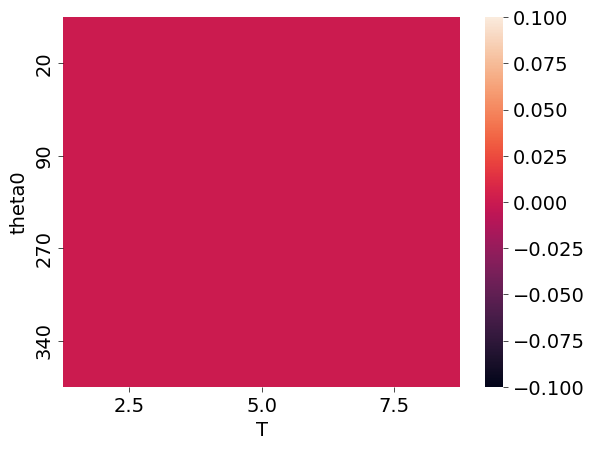

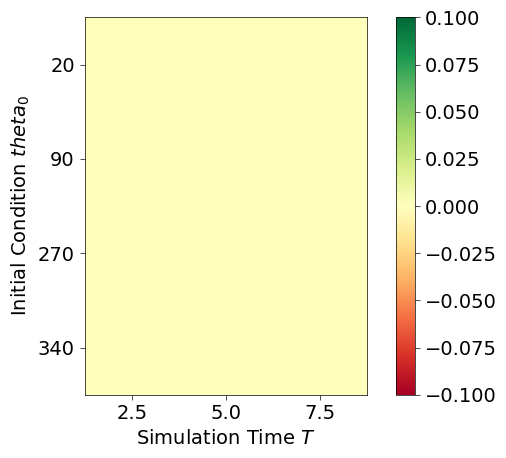

In [3]:
results = pd.read_csv("results_no_reg.csv")


table = pd.pivot_table(results, values="loss_successes_percent", 
                        index=["theta0"],
                        columns=["T"],
                        aggfunc="mean")
sns.heatmap(table)
plt.show()

fig, ax = plt.subplots()

ims = ax.imshow(table, cmap='RdYlGn')
fig.colorbar(ims)

ax.set_xticks(range(table.shape[1]))
ax.set_xticklabels(table.columns, rotation=0)
ax.set_xlabel(r'Simulation Time $T$')

ax.set_yticks(range(table.shape[0]))
ax.set_yticklabels(table.index)
ax.set_ylabel(r'Initial Condition $theta_0$')


plt.tight_layout()
plt.show()

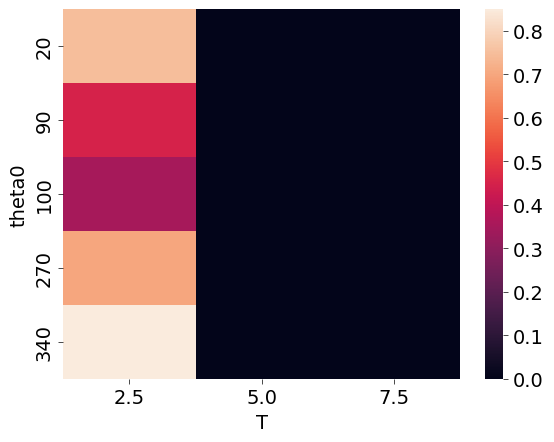

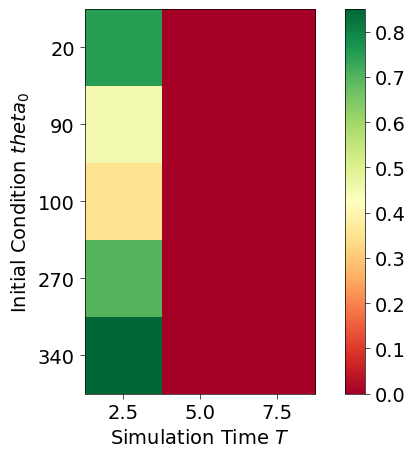

In [4]:
results = pd.read_csv("results_reg_full.csv")


table = pd.pivot_table(results, values="loss_successes_percent", 
                        index=["theta0"],
                        columns=["T"],
                        aggfunc="mean")
sns.heatmap(table)
plt.show()

fig, ax = plt.subplots()

ims = ax.imshow(table, cmap='RdYlGn')
fig.colorbar(ims)

ax.set_xticks(range(table.shape[1]))
ax.set_xticklabels(table.columns, rotation=0)
ax.set_xlabel(r'Simulation Time $T$')

ax.set_yticks(range(table.shape[0]))
ax.set_yticklabels(table.index)
ax.set_ylabel(r'Initial Condition $theta_0$')


plt.tight_layout()
plt.show()

T-theta0 5-100, regularizing stability


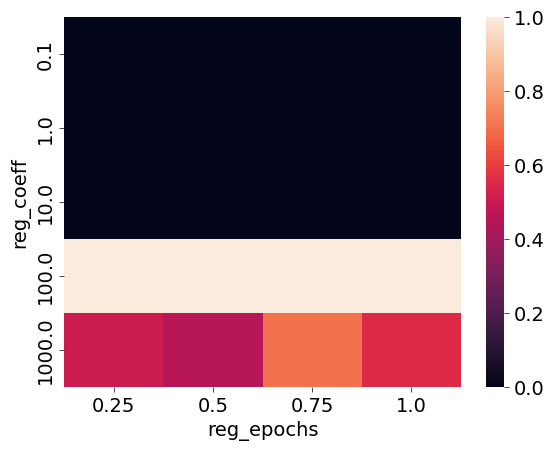

T-theta0 5-100,  regularizing distance to fixed point


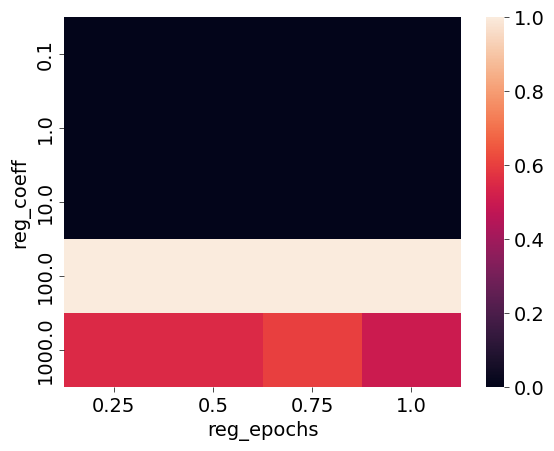

T-theta0 5-100, regularizing stability around the fixed point


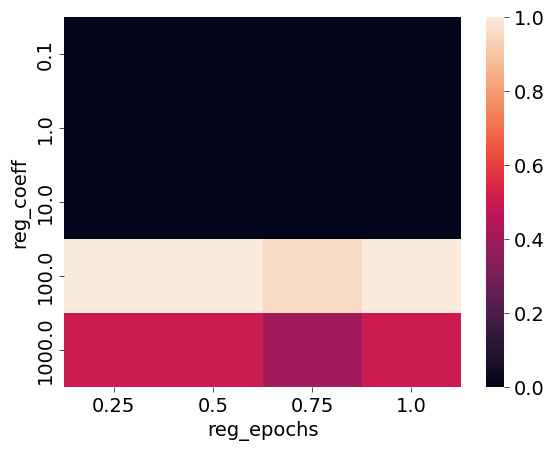

In [5]:
regularization_names = {
    "reg_derivative": " regularizing distance to fixed point",
    "unstable_fp": "regularizing stability",
    "reg_derivative_unstable_fp": "regularizing stability around the fixed point"
}

results = pd.read_csv("results_linear_decay.csv")

dirname = "grid_search_results"

if not os.path.exists(dirname):
    os.makedirs(dirname)

results["T-theta0"] = results["T"].astype(str) + "-" + results["theta0"].astype(str)

for settings in results["T-theta0"].unique():
    for regularization in results["regularization"].unique():
        results_subset = results.loc[(results["T-theta0"] == settings) & (results["regularization"] == regularization)]
        table = pd.pivot_table(results_subset, values="loss_successes_percent", index="reg_coeff", columns="reg_epochs")
        sns.heatmap(table)
        # plt.title(f"T-theta0 {settings}, {regularization_names[regularization]}")
        print(f"T-theta0 {settings}, {regularization_names[regularization]}")
        plt.savefig(f"{dirname}/inverted_undamped_pendulum_example_results_{regularization}_settingsT-theta0_{settings}.png")
        plt.show()

T-theta0 2.5-20,  regularizing distance to fixed point


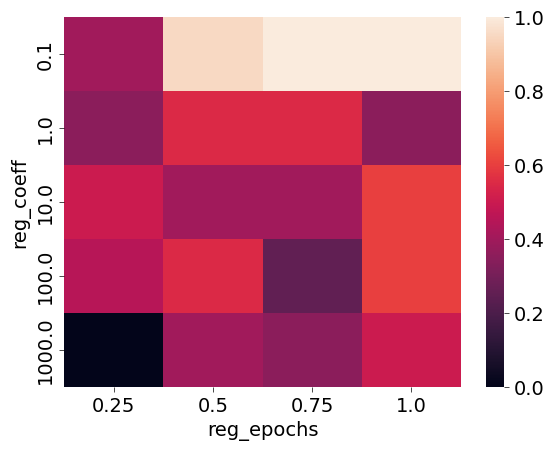

T-theta0 2.5-20, regularizing stability around the fixed point


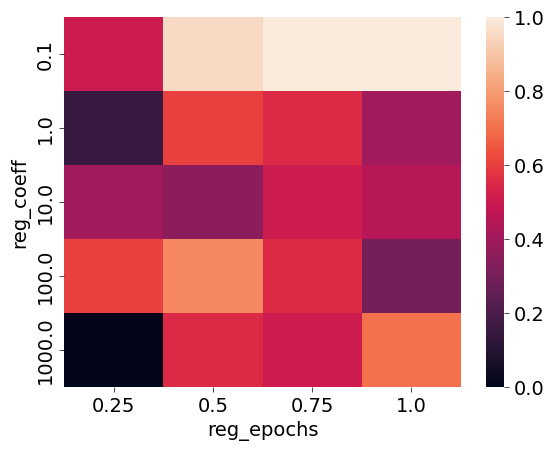

T-theta0 2.5-20, regularizing stability


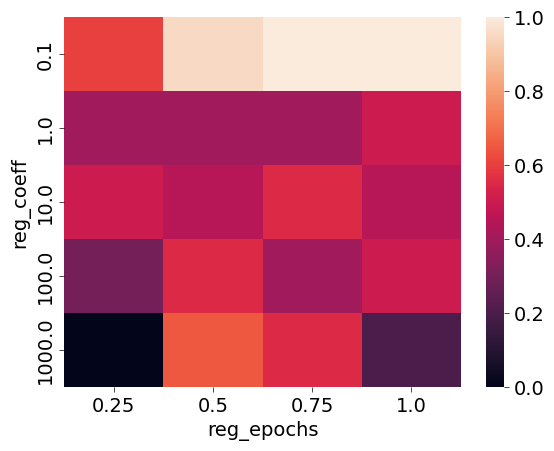

T-theta0 2.5-90,  regularizing distance to fixed point


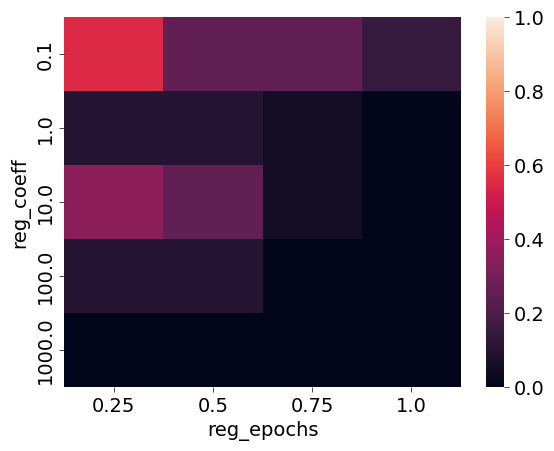

T-theta0 2.5-90, regularizing stability around the fixed point


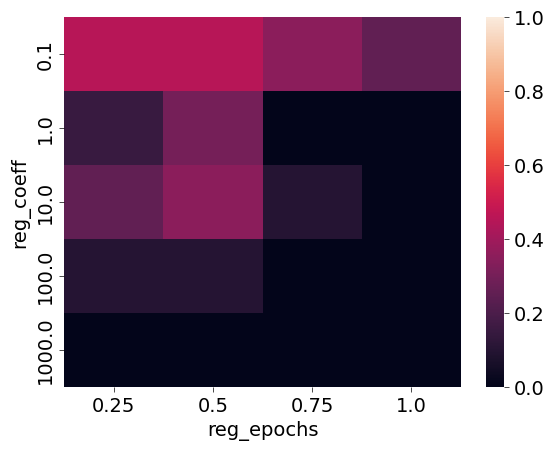

T-theta0 2.5-90, regularizing stability


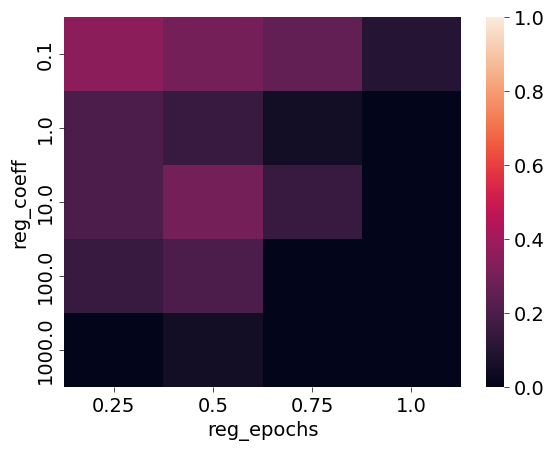

T-theta0 2.5-100,  regularizing distance to fixed point


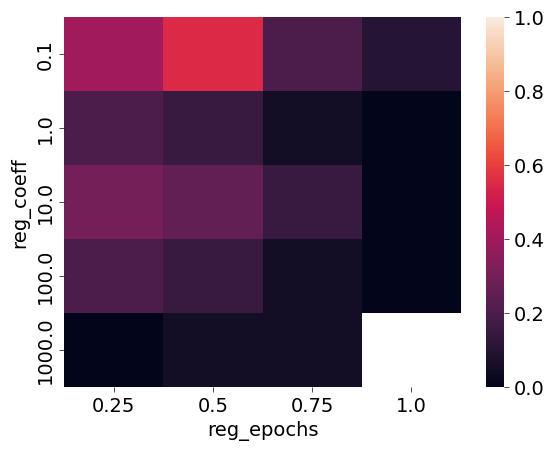

T-theta0 2.5-100, regularizing stability around the fixed point


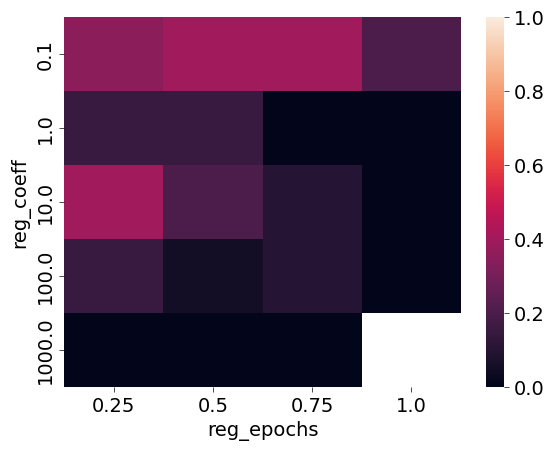

T-theta0 2.5-100, regularizing stability


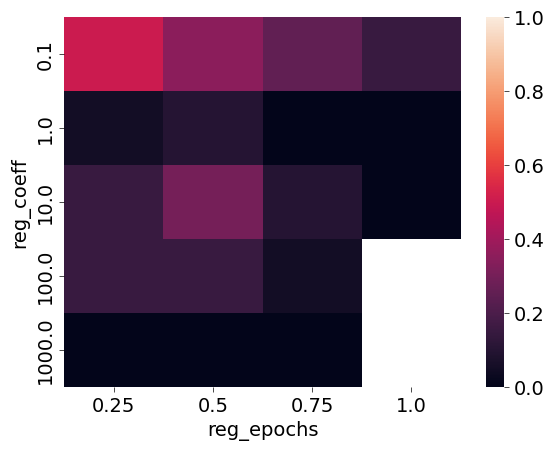

In [7]:
regularization_names = {
    "reg_derivative": " regularizing distance to fixed point",
    "unstable_fp": "regularizing stability",
    "reg_derivative_unstable_fp": "regularizing stability around the fixed point"
}

results = pd.read_csv("results_linear_decay_new.csv")

dirname = "grid_search_results"

if not os.path.exists(dirname):
    os.makedirs(dirname)

results["T-theta0"] = results["T"].astype(str) + "-" + results["theta0"].astype(str)

for settings in results["T-theta0"].unique():
    for regularization in results["regularization"].unique():
        results_subset = results.loc[(results["T-theta0"] == settings) & (results["regularization"] == regularization)]
        table = pd.pivot_table(results_subset, values="loss_successes_percent", index="reg_coeff", columns="reg_epochs")
        table.to_csv(f"{dirname}/inverted_undamped_pendulum_example_results_{regularization}_settingsT-theta0_{settings}.csv")
        sns.heatmap(table, vmin=0, vmax=1.0)
        # plt.title(f"T-theta0 {settings}, {regularization_names[regularization]}")
        print(f"T-theta0 {settings}, {regularization_names[regularization]}")
        plt.savefig(f"{dirname}/inverted_undamped_pendulum_example_results_{regularization}_settingsT-theta0_{settings}.png")
        plt.show()